In [1]:
import geopandas as gpd
import pandas as pd

import os
os.getcwd()

import pickle

## Input data

In [2]:
local_crs = 32637 # Tula region crs 

<Axes: >

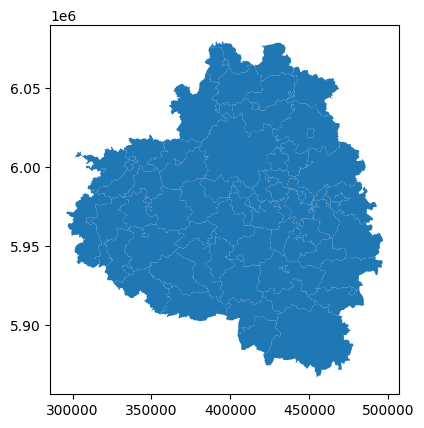

In [3]:
municipalities_polygons = gpd.read_file("data/tula_region_municipalities.geojson").to_crs(local_crs)
municipalities_polygons.plot()

Get the project territory

<Axes: >

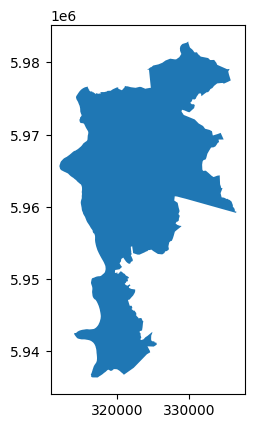

In [4]:
territory = municipalities_polygons.iloc[[4]]
territory.plot()

Get settlement points

In [5]:
settlement_points = gpd.read_file("data/tula_region_towns.geojson").to_crs(local_crs)

Get the context polygons

In [6]:
target_geom = territory.geometry.union_all()
target_idx = territory.index[0]

context = municipalities_polygons[
    (municipalities_polygons.index != target_idx)
    & (municipalities_polygons.geometry.touches(target_geom))
].copy()

<Axes: >

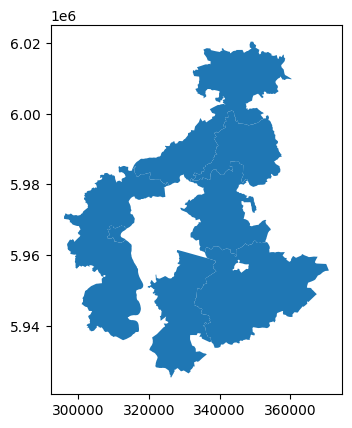

In [7]:
context.plot()

Get the adjacency matrix between the settlement points

In [8]:
with open("data/G_drive.pickle", "rb") as f:
    G_drive = pickle.load(f)

In [9]:
import iduedu 

mx = iduedu.get_adj_matrix_gdf_to_gdf(gdf_from = settlement_points, gdf_to = settlement_points, nx_graph = G_drive, weight = "time_min")

2026-04-05 01:35:46.527 | WARNING  | Removing 197 nodes from 22 smaller strongly connected components. These are subgraphs where nodes are internally reachable but isolated from the rest. Retaining only the largest strongly connected component (31927 nodes).


## Method

In [10]:
settlement_points = settlement_points.reset_index(drop=True).copy()
settlement_points["territory_id"] = settlement_points.index.astype(int)

ids = settlement_points["territory_id"].tolist()
mx = mx.copy()
mx.index = ids
mx.columns = ids

In [11]:
from transport_frames.context_accessibility import get_context_connectivity

con = get_context_connectivity(settlement_points, context, mx, municipalities_polygons, local_crs)


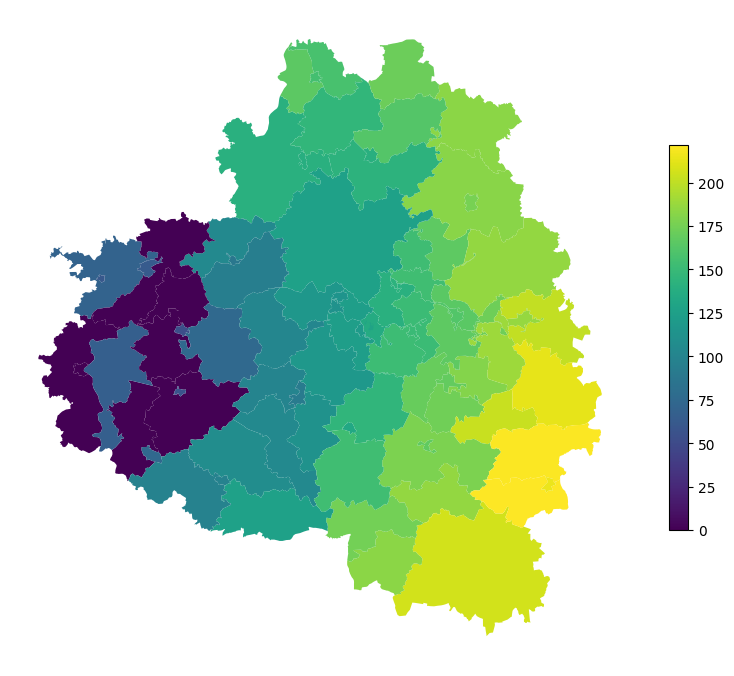

In [12]:
import matplotlib.pyplot as plt

fin_webm  = con.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(10, 10))
fin_webm.plot(
    column="median_connectivity",
    legend=True,
    legend_kwds={'shrink':0.5},
    ax=ax,
)

ax.set_axis_off()
plt.show()
